In [2]:
import pandas as pd
import spacy
from wordcloud import STOPWORDS
import string
from string import punctuation
import nltk
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report,f1_score
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectFromModel

from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
import numpy as np
from nltk.sentiment.vader import SentimentIntensityAnalyzer as VS
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import matplotlib.pyplot as plt

%matplotlib inline

In [3]:
df=pd.read_csv(r"D:\jangoProject\HateSpeechData.csv")
df.sample(5)

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
14274,14616,3,0,2,1,1,RT @BORNhvstler: If I see a bitch coming at me...
6361,6543,3,0,3,0,1,@kay_reneaa holy fuck thank you. I hate bitche...
8164,8391,3,0,3,0,1,"Boys want bad bitches , and dummies. Men want ..."
9575,9835,3,0,3,0,1,Greinke you sneaky son of a bitch you
17734,18135,3,0,3,0,1,RT @TheVoiceOfMiami I don't work for pussy... ...


In [4]:
#adding text length to dataset
df['text_length']=df['tweet'].apply( lambda x:len(x))
df.head()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet,text_length
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...,140
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,85
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,120
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,62
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,137


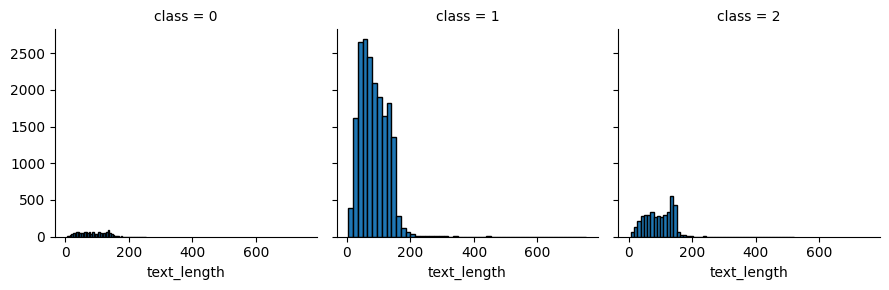

In [5]:
#Basic visualization of data using histograms
# FacetGrid- Multi-plot grid for plotting conditional relationships 
graph=sns.FacetGrid(data=df, col='class')
graph.map(plt.hist, 'text_length', bins=50, edgecolor='black', linewidth=1)


a. Distribution of text-length almost seem to be similar across all three classes
b. Number of tweets seem to be skewed a lot higher towards the class-1

<Axes: xlabel='class', ylabel='text_length'>

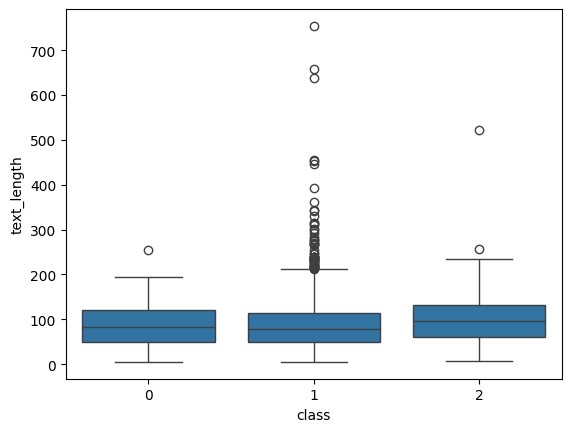

In [5]:
sns.boxplot(x='class', y= 'text_length',data=df)

From the box-plot, looks like the class-1 tweets have much longer text. There are also outliers present so text-length won’t be a useful feature to consider.

In [6]:
import re
import pandas as pd
import spacy
from string import punctuation
from wordcloud import STOPWORDS

# Load spaCy model without ner and parser for speed
nlp = spacy.load('en_core_web_sm', disable=['ner', 'parser'])

other_exclusions = ["#ff", "ff", "rt"]
stop_words = STOPWORDS.union(set(punctuation)).union(set(other_exclusions))

def fast_cleaning(tweets_series):
    tweets_series = tweets_series.str.replace(r'http\S+|www\S+|https\S+', '', regex=True, flags=re.IGNORECASE)
    tweets_series = tweets_series.str.replace(r'@\w+', '', regex=True)
    tweets_series = tweets_series.str.replace(r'[^a-zA-Z\s]', ' ', regex=True)
    tweets_series = tweets_series.str.replace(r'\s+', ' ', regex=True)
    tweets_series = tweets_series.str.strip().str.lower()
    return tweets_series

def spacy_tokenize_and_lemmatize_batch(texts):
    docs = nlp.pipe(texts, batch_size=50)
    results = []
    for doc in docs:
        lemmas = [
            token.lemma_ for token in doc
            if token.lemma_.lower() not in stop_words and not token.is_punct and not token.is_space
        ]
        results.append(lemmas)
    return results

def hybrid_preprocess(df, column):
    cleaned_text = fast_cleaning(df[column])
    processed_tokens = spacy_tokenize_and_lemmatize_batch(cleaned_text)


    return processed_tokens

# Example usage:
# Assume df is your DataFrame and 'tweet' is the text column
df['processed_tweet'] = hybrid_preprocess(df, 'tweet')

print(df['processed_tweet'].head())


0    [woman, shouldn, t, complain, clean, house, am...
1    [boy, dat, cold, tyga, dwn, bad, cuffin, dat, ...
2       [dawg, fuck, bitch, start, cry, confuse, shit]
3                                       [look, tranny]
4    [shit, hear, might, true, might, faker, bitch,...
Name: processed_tweet, dtype: object


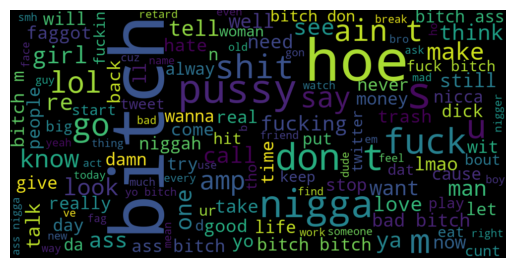

In [7]:
# visualizing which of the word is most commonly used for offensive speech

from wordcloud import WordCloud, STOPWORDS 
stopwords=STOPWORDS
all_word=' '.join([' '.join(text) for text in df['processed_tweet'][df['class']==1]])

wordcloud=WordCloud(width=1000, height=500,max_words=1000, min_font_size=20, max_font_size=150,background_color='black',
                    stopwords=stopwords, random_state=20).generate(all_word)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


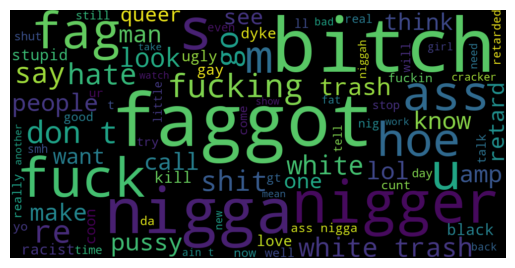

In [8]:
# visualizing which of the word is most commonly used for hatred speech

all_word=' '.join([' '.join(token) for token in df['processed_tweet'][df['class']==0]])
wordcloud=WordCloud(width=1000, height=500,max_words=1000, min_font_size=20, max_font_size=150,background_color='black',
                    stopwords=stopwords, random_state=42).generate(all_word)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


In [7]:
df['processed_tweet_str'] = df['processed_tweet'].apply(lambda tokens: ' '.join(tokens))

# Now use TfidfVectorizer on the string column
from sklearn.feature_extraction.text import TfidfVectorizer

TfidfVectorizer_mode = TfidfVectorizer(max_df=0.65, min_df=5, ngram_range=(1, 2))
TfidfVectorizer_matrix = TfidfVectorizer_mode.fit_transform(df['processed_tweet_str'])



In [8]:
target=TfidfVectorizer_matrix
label= df['class']
X_train,X_test,y_train,y_test=train_test_split(target,label,test_size=.25,random_state=42)
model=LogisticRegression().fit(X_train,y_train)
y_pred=model.predict(X_test)
accuracy=accuracy_score(y_test, y_pred)
report=classification_report(y_test,y_pred)
print(report)
print('accuracy: ',accuracy)


              precision    recall  f1-score   support

           0       0.51      0.15      0.23       361
           1       0.92      0.96      0.94      4794
           2       0.85      0.86      0.85      1041

    accuracy                           0.90      6196
   macro avg       0.76      0.66      0.68      6196
weighted avg       0.88      0.90      0.88      6196

accuracy:  0.8989670755326017


In [9]:
target=TfidfVectorizer_matrix
label=df['class']
X_train,X_test,y_train,y_test=train_test_split(target,label,test_size=.25, random_state=42)
model=RandomForestClassifier().fit(X_train,y_train)
y_pred=model.predict(X_test)
accuracy1=accuracy_score(y_test,y_pred)
report=classification_report(y_test,y_pred)
print('accuracy',accuracy)
print("Random Forest, Accuracy Score:",report)

accuracy 0.8989670755326017
Random Forest, Accuracy Score:               precision    recall  f1-score   support

           0       0.50      0.16      0.24       361
           1       0.93      0.96      0.94      4794
           2       0.82      0.91      0.87      1041

    accuracy                           0.90      6196
   macro avg       0.75      0.68      0.68      6196
weighted avg       0.89      0.90      0.89      6196



GaussianNB is a straightforward, efficient classification algorithm that leverages 
the assumption of normally distributed features and conditional independence to make 
probabilistic predictions.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(target.toarray(), label, random_state=42, test_size=0.2)
model=GaussianNB().fit(X_train,y_train)
y_pred=model.predict(X_test)
accuracy2=accuracy_score(y_test,y_pred)
report=classification_report(y_test,y_pred)
print('accuracy',accuracy)
print(", Accuracy Score:",report)



accuracy 0.8989670755326017
, Accuracy Score:               precision    recall  f1-score   support

           0       0.09      0.37      0.15       290
           1       0.89      0.68      0.77      3832
           2       0.54      0.58      0.55       835

    accuracy                           0.64      4957
   macro avg       0.51      0.54      0.49      4957
weighted avg       0.78      0.64      0.70      4957



In [17]:
 #LinearSVC is commonly used for text classification,image recognition, and other applications where the data is (or can be made) linearly separable.
support=LinearSVC(random_state=20) 
support.fit(X_train,y_train)
y_pred=support.predict(X_test)
accuracy3=accuracy_score(y_test,y_pred)
report=classification_report(y_test,y_pred)
print('accuracy',accuracy)
print(", Accuracy Score:",report)

tr='!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...	'

accuracy 0.8989670755326017
, Accuracy Score:               precision    recall  f1-score   support

           0       0.47      0.26      0.33       290
           1       0.93      0.95      0.94      3832
           2       0.83      0.85      0.84       835

    accuracy                           0.89      4957
   macro avg       0.74      0.69      0.70      4957
weighted avg       0.88      0.89      0.89      4957



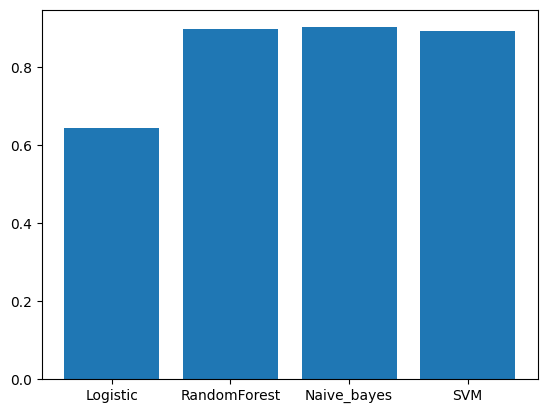

In [18]:
objects=('Logistic', 'RandomForest', 'Naive_bayes', 'SVM')
performance=[accuracy2,accuracy,accuracy1,accuracy3]
plt.bar(range(len(performance)),performance)
plt.xticks(range(len(objects)),objects)
plt.show()

In [10]:
import re
import numpy as np
from nltk.sentiment.vader import SentimentIntensityAnalyzer as VS
import pandas as pd

# Initialize the sentiment analyzer
sentiment_analyzer = VS()

def count_tag(tweet_c): 
    space_pat = r'\s+'
    hashtag_pat = r'#[\w\-]+'
    mention_pat = r'@[\w\-]+'
    url_pat = (
        r'(?:http[s]?://|www\.)'  # Protocol or www.
        r'(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
    )
    
    parsed_text = re.sub(space_pat, ' ', tweet_c)
    parsed_text = re.sub(url_pat, 'URLHERE', parsed_text)
    parsed_text = re.sub(hashtag_pat, 'HASHTAGHERE', parsed_text)
    parsed_text = re.sub(mention_pat, 'MENTIONHERE', parsed_text)
    
    return (parsed_text.count('MENTIONHERE'), parsed_text.count('HASHTAGHERE'), parsed_text.count('URLHERE'))

def sentiment_analysis(tweet):  
    sentiment = sentiment_analyzer.polarity_scores(tweet)
    twitter_objs = count_tag(tweet)
    features = [sentiment['pos'], sentiment['neg'], sentiment['neu'], sentiment['compound'], twitter_objs[0], twitter_objs[1], twitter_objs[2]]
    return features

def sentiment_analysis_array(tweets):
    features = []
    for t in tweets:
        features.append(sentiment_analysis(t))
    return np.array(features)

# Assuming df is defined and contains a 'tweet' column
final_features = sentiment_analysis_array(df['tweet'])
new_features = pd.DataFrame({
    'Pos': final_features[:, 0],
    'Neg': final_features[:, 1],
    'Neu': final_features[:, 2],
    'Compound': final_features[:, 3],
    'mention_tag': final_features[:, 4],
    'hash_tag': final_features[:, 5],
    'url_tag': final_features[:, 6]
})

new_features




,Pos,Neg,Neu,Compound,mention_tag,hash_tag,url_tag
0,0.120,0.000,0.880,0.4563,1.0,0.0,0.0
1,0.000,0.237,0.763,-0.6876,1.0,0.0,0.0
2,0.000,0.538,0.462,-0.9550,2.0,0.0,0.0
3,0.344,0.000,0.656,0.5673,2.0,0.0,0.0
4,0.081,0.249,0.669,-0.7762,1.0,1.0,0.0
...,...,...,...,...,...,...,...
24778,0.000,0.000,1.000,0.0000,3.0,3.0,0.0
24779,0.000,0.454,0.546,-0.8074,0.0,0.0,0.0
24780,0.219,0.000,0.781,0.4738,0.0,0.0,0.0
24781,0.000,0.573,0.427,-0.7717,0.0,0.0,0.0


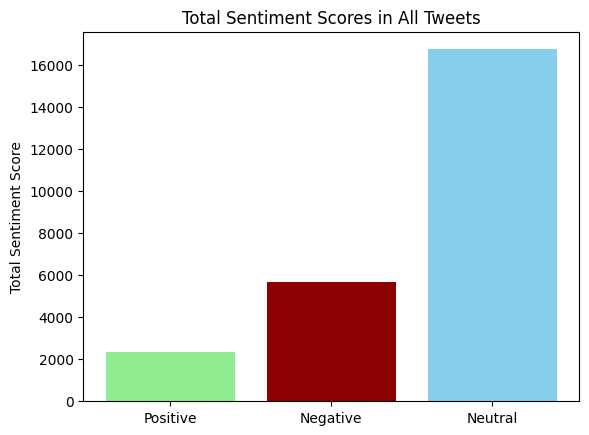

In [11]:
# First run your existing analysis code (without changes)
final_features = sentiment_analysis_array(df['tweet'])



sentiment_counts = {
    'Positive': (new_features['Pos'].sum()),
    'Negative': (new_features['Neg'].sum()),
    'Neutral': (new_features['Neu'].sum())
    
}

# Create the bar chart
plt.bar(sentiment_counts.keys(), sentiment_counts.values(),
        color=['lightgreen', 'darkred', 'skyblue','y'])
plt.title('Total Sentiment Scores in All Tweets')
plt.ylabel('Total Sentiment Score')

# Show the plot
plt.show()


In [12]:
tfidf_arr=TfidfVectorizer_matrix.toarray()   
model_feature=np.concatenate([tfidf_arr,new_features.values],axis=1)
model_feature.shape

(24783, 6249)

In [16]:
target=(model_feature ) 

label=df['class']
X_train, X_test,y_train, y_test=train_test_split(target, label, test_size=0.25, random_state=42)
regression=LogisticRegression().fit(X_train,y_train)
y_pred=regression.predict(X_test)

accuracy=accuracy_score(y_test,y_pred)
report=classification_report(y_test,y_pred)
print('LogisticRegression accuracy: ',accuracy)
print( report)


LogisticRegression accuracy:  0.8978373143963848
              precision    recall  f1-score   support

           0       0.53      0.15      0.24       361
           1       0.92      0.96      0.94      4794
           2       0.85      0.85      0.85      1041

    accuracy                           0.90      6196
   macro avg       0.76      0.66      0.68      6196
weighted avg       0.88      0.90      0.88      6196



c:\Users\mina\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [20]:

X_train_for, X_test_for,y_train_for, y_test_for=train_test_split(target, label, test_size=0.25, random_state=42)
regression=RandomForestClassifier().fit(X_train_for,y_train_for)
y_pred=regression.predict(X_test_for)
accuracy1=accuracy_score(y_test_for,y_pred)
report=classification_report(y_test_for,y_pred)
print('randomforest accuracy: ',accuracy)
print( report)

randomforest accuracy:  0.8978373143963848
              precision    recall  f1-score   support

           0       0.52      0.12      0.20       361
           1       0.91      0.97      0.94      4794
           2       0.84      0.85      0.85      1041

    accuracy                           0.90      6196
   macro avg       0.76      0.64      0.66      6196
weighted avg       0.88      0.90      0.88      6196



In [22]:

X_train_GB, X_test_GB,y_train_GB, y_test_GB=train_test_split(target, label, test_size=0.25, random_state=42)
regression=GaussianNB().fit(X_train_GB,y_train_GB)
y_pred=regression.predict(X_test_GB)
accuracy2=accuracy_score(y_test_GB,y_pred)
report=classification_report(y_test,y_pred)
print('Naive Bayes accuracy: ',accuracy)
print( report)

Naive Bayes accuracy:  0.8978373143963848
              precision    recall  f1-score   support

           0       0.09      0.35      0.15       361
           1       0.89      0.69      0.78      4794
           2       0.54      0.59      0.57      1041

    accuracy                           0.65      6196
   macro avg       0.51      0.54      0.50      6196
weighted avg       0.79      0.65      0.71      6196



In [23]:

X_train_S, X_test_S,y_train_S, y_test_S=train_test_split(target, label, test_size=0.25, random_state=20)
regression=LinearSVC().fit(X_train_S,y_train_S)
y_pred=regression.predict(X_test_S)
accuracy3=accuracy_score(y_test_S,y_pred)
report=classification_report(y_test_S,y_pred)
print('SVM accuracy: ',accuracy)
print( report)

SVM accuracy:  0.8978373143963848
              precision    recall  f1-score   support

           0       0.49      0.27      0.35       330
           1       0.93      0.95      0.94      4845
           2       0.84      0.84      0.84      1021

    accuracy                           0.90      6196
   macro avg       0.75      0.69      0.71      6196
weighted avg       0.89      0.90      0.89      6196



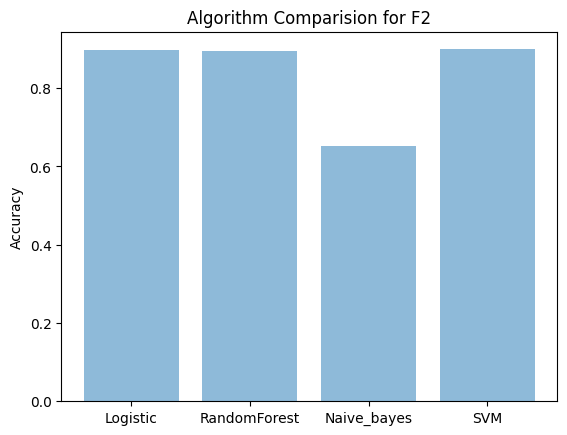

In [24]:
objects = ('Logistic', 'RandomForest', 'Naive_bayes', 'SVM')
y_pos = np.arange(len(objects))
performance = [accuracy,accuracy1,accuracy2,accuracy3]
plt.bar(y_pos, performance, align='center', alpha=0.5)
plt.xticks(y_pos, objects)
plt.ylabel('Accuracy')
plt.title('Algorithm Comparision for F2')
plt.show()

In [17]:
def predict_sentiment(tweet):
    # Get sentiment features for the new tweet
    tweet_features = sentiment_analysis(tweet)  # Pass the tweet directly as a string
    tweet_df = pd.DataFrame([tweet_features], columns=new_features.columns)  # Match training format
    
    # Transform the new tweet using the fitted TfidfVectorizer
    tweet_tfidf = TfidfVectorizer_mode.transform([tweet]).toarray()  # Use the same vectorizer
    
    # Combine the TF-IDF features with the sentiment features for the new tweet
    final_input = np.concatenate([tweet_tfidf, tweet_df.values], axis=1)
    
    # Make the prediction
    prediction = regression.predict(final_input)
    
    # Interpret the prediction
    return "Positive" if prediction[0] == 2 else "Negative" if prediction[0] == 1 else "Neutral" if prediction[0] == 0 else "Compound"

# Example usage
new_tweet = "bitch nigga miss me with it"
predicted_sentiment = predict_sentiment(new_tweet)
print(f"The predicted sentiment for the tweet '{new_tweet}' is: {predicted_sentiment}")



The predicted sentiment for the tweet 'bitch nigga miss me with it' is: Negative


from gensim.test.utils import common_texts:

This line imports a small sample dataset called common_texts from Gensim, which is often used for testing and demonstration purposes. However, in the provided code, it seems you are not using common_texts directly.
from gensim.models.doc2vec import Doc2Vec, TaggedDocument:

This line imports the Doc2Vec model and the TaggedDocument class from the Gensim library.
Doc2Vec is a model that generates vector representations for entire documents, extending the Word2Vec model.
TaggedDocument is a data structure used to represent documents with associated tags (identifiers).

In [13]:
from gensim.test.utils import common_texts
from gensim.models.doc2vec import Doc2Vec, TaggedDocument

# 1. Prepare tagged documents
documents = [TaggedDocument(words=doc.split(), tags=[i]) 
            for i, doc in enumerate(df['processed_tweet_str'])]  # Pre-split if possible

# 2. Train model with proper parameters
model = Doc2Vec(
    documents,
    vector_size=300,      # More standard dimension than 5
    window=5,            # Larger context window (2 is very small)
    min_count=2,         # Ignore very rare words (1 keeps everything)
    epochs=20,           # Sufficient training iterations
    workers=4,           # Parallel processing
    dm=0,                # Explicit PV-DBOW mode
    hs=1,                # Hierarchical softmax often works better
    negative=5           # Negative sampling
)

# 3. Build vocabulary explicitly (better practice)
model.build_vocab(documents)

# 4. Infer vectors with optimization
doc2vec_df = df["processed_tweet_str"].apply(
    lambda x: model.infer_vector(
        x.split(),
        epochs=20,       # Sufficient inference iterations 
        alpha=0.025      # Initial learning rate
    )
).apply(pd.Series)

doc2vec_df.columns = [f"doc2vec_{i}" for i in range(model.vector_size)]
doc2vec_df.columns


Index(['doc2vec_0', 'doc2vec_1', 'doc2vec_2', 'doc2vec_3', 'doc2vec_4',
       'doc2vec_5', 'doc2vec_6', 'doc2vec_7', 'doc2vec_8', 'doc2vec_9',
       ...
       'doc2vec_290', 'doc2vec_291', 'doc2vec_292', 'doc2vec_293',
       'doc2vec_294', 'doc2vec_295', 'doc2vec_296', 'doc2vec_297',
       'doc2vec_298', 'doc2vec_299'],
      dtype='object', length=300)

In [14]:
# conctaenation of tf-idf scores, sentiment scores and doc2vec columns
modelling_features=np.concatenate([tfidf_arr,new_features.values,doc2vec_df],axis=1)
modelling_features.shape


(24783, 6549)

In [15]:
target=modelling_features
label=df['class']
X_train,X_test,y_train,y_test=train_test_split(target,label,test_size=0.20,random_state=42)
model=LogisticRegression().fit(X_train,y_train)
y_pred=model.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
report=classification_report(y_test,y_pred)
print('accuracy of regression ',accuracy)
print(report)

accuracy of regression  0.8991325398426467
              precision    recall  f1-score   support

           0       0.55      0.17      0.26       290
           1       0.92      0.96      0.94      3832
           2       0.85      0.85      0.85       835

    accuracy                           0.90      4957
   macro avg       0.77      0.66      0.68      4957
weighted avg       0.88      0.90      0.89      4957



c:\Users\mina\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [76]:
target=pd.DataFrame(target)
X_train_bow,X_test_bow,y_train,y_test=train_test_split(target,label,test_size=0.20,random_state=42)
rf=RandomForestClassifier().fit(X_train_bow,y_train)
y_preds = rf.predict(X_test_bow)
accuracy1=accuracy_score(y_test,y_preds)
report = classification_report( y_test, y_preds )
print(report)
print("Random Forest, Accuracy Score:",accuracy1)

              precision    recall  f1-score   support

           0       0.22      0.02      0.03       290
           1       0.84      0.99      0.91      3832
           2       0.90      0.45      0.60       835

    accuracy                           0.84      4957
   macro avg       0.65      0.48      0.51      4957
weighted avg       0.81      0.84      0.80      4957

Random Forest, Accuracy Score: 0.839217268509179


In [77]:
X_train_bow,X_test_bow,y_train,y_test=train_test_split(target,label,test_size=0.20,random_state=42)
nb=GaussianNB()
nb.fit(X_train,y_train)
y_preds = nb.predict(X_test)
accuracy2=accuracy_score(y_test,y_preds)
report = classification_report( y_test, y_preds )
print(report)
print("Naive Bayes, Accuracy Score:",accuracy2)

              precision    recall  f1-score   support

           0       0.09      0.37      0.15       290
           1       0.89      0.68      0.77      3832
           2       0.54      0.58      0.56       835

    accuracy                           0.64      4957
   macro avg       0.51      0.54      0.49      4957
weighted avg       0.79      0.64      0.70      4957

Naive Bayes, Accuracy Score: 0.6445430704054872


In [78]:
X_train_bow,X_test_bow,y_train,y_test=train_test_split(target,label,test_size=0.20,random_state=42)
support=LinearSVC().fit(X_train,y_train)
y_preds = support.predict(X_test)
accuracy3=accuracy_score(y_test,y_preds)
report = classification_report( y_test, y_preds )
print(report)
print("Naive Bayes, Accuracy Score:",accuracy3)

              precision    recall  f1-score   support

           0       0.46      0.25      0.32       290
           1       0.93      0.95      0.94      3832
           2       0.83      0.86      0.84       835

    accuracy                           0.89      4957
   macro avg       0.74      0.69      0.70      4957
weighted avg       0.88      0.89      0.89      4957

Naive Bayes, Accuracy Score: 0.8936856969941497


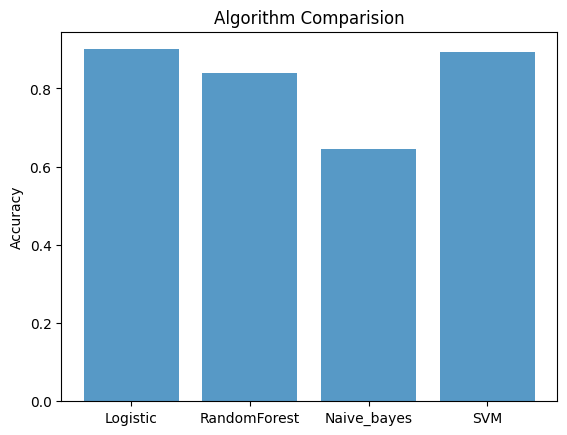

In [101]:
object=['regression', 'RandomForestClassifier','GaussianNB','LinearSVC']
performance=[accuracy, accuracy1,accuracy2,accuracy3]
plt.bar(range(len(performance)), performance, align='center',alpha=0.75)
plt.xticks(range(len(object)),objects)
plt.ylabel('Accuracy')
plt.title('Algorithm Comparision')
plt.show()

In [16]:
import numpy as np
import textstat

# Using TFIDF with sentiment scores, doc2vec, and enhanced features
def additional_features(tweet):
    if not isinstance(tweet, str) or not tweet.strip():
        return [0] * 8  # Return a list of zeros if the tweet is not valid

    syllables = textstat.syllable_count(tweet)
    num_chars = sum(len(w) for w in tweet if w.strip())  # Count characters excluding spaces
    num_chars_total = len(tweet)
    num_words = len(tweet.split())
    
    # Average syllables per word
    avg_syl = round(float((syllables + 0.001)) / float(num_words + 0.001), 4)
    num_unique_terms = len(set(tweet.split()))

    # Calculate Flesch-Kincaid readability scores
    FKRA = round(float(0.39 * float(num_words) / 1.0) + float(11.8 * avg_syl) - 15.59, 1)
    FRE = round(206.835 - 1.015 * (float(num_words) / 1.0) - (84.6 * float(avg_syl)), 2)

    add_features = [FKRA, FRE, syllables, avg_syl, num_chars, num_chars_total, num_words, num_unique_terms]
    return add_features

def get_additional_feature_array(tweets):
    features = []
    for t in tweets:
        features.append(additional_features(t))
    return np.array(features)

# Example usage
fFeatures = get_additional_feature_array(df['processed_tweet_str'])

print(fFeatures)


[[  3.7   88.    14.   ...  62.    11.    11.  ]
 [  2.6   95.69  13.   ...  49.    11.    10.  ]
 [  0.6  103.05   8.   ...  38.     7.     7.  ]
 ...
 [  3.8   82.39  11.   ...  42.     8.     8.  ]
 [ -1.8  117.16   5.   ...  26.     5.     5.  ]
 [ 11.3   37.46  24.   ...  87.    13.    13.  ]]


In [17]:
model_sylaabe_features=np.concatenate([tfidf_arr,doc2vec_df,fFeatures],axis=1)
model_sylaabe_features.shape

(24783, 6550)

In [19]:

X = model_sylaabe_features
y = df['class'].astype(int)
X_train_features, X_test_features, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.2)

model = LogisticRegression().fit(X_train_features,y_train)
y_preds = model.predict(X_test_features)
report = classification_report( y_test, y_preds )
print(report)
acc=accuracy_score(y_test,y_preds)
print("Logistic Regression, Accuracy Score:" , acc)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       279
           1       0.82      0.98      0.89      3852
           2       0.63      0.27      0.37       826

    accuracy                           0.80      4957
   macro avg       0.48      0.41      0.42      4957
weighted avg       0.74      0.80      0.75      4957

Logistic Regression, Accuracy Score: 0.8035101876134759


c:\Users\mina\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


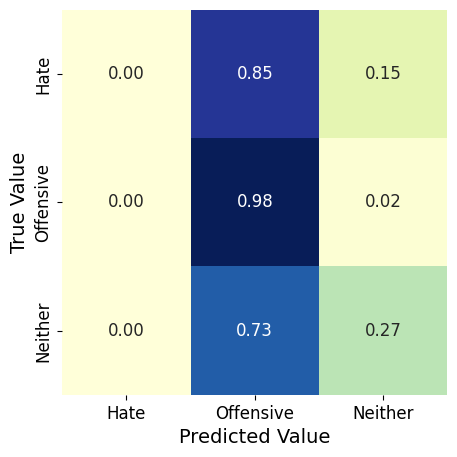

In [22]:
import numpy as np
import pandas as pd  # Corrected import for pandas
import matplotlib.pyplot as plt
import seaborn as sns  # Assuming seaborn is imported as sns
from sklearn.metrics import confusion_matrix 

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_preds)

# Initialize the proportions matrix
matrix_proportions = np.zeros((3, 3))

# Calculate proportions for each class
for i in range(0, 3):
    total = float(cm[i, :].sum())
    
    if total > 0:
        matrix_proportions[i, :] = cm[i, :] / total
    else:
        matrix_proportions[i, :] = np.zeros(3)  # Handle the case where there are no instances

# Define class names
names = ['Hate', 'Offensive', 'Neither']

# Create a DataFrame for the confusion matrix proportions
confusion_df = pd.DataFrame(matrix_proportions, index=names, columns=names)

# Set up the figure for the heatmap
plt.figure(figsize=(5, 5))

# Create the heatmap
sns.heatmap(confusion_df, annot=True, annot_kws={"size": 12}, cmap='YlGnBu', cbar=False, square=True, fmt='.2f')

# Label the axes
plt.ylabel(r'True Value', fontsize=14)
plt.xlabel(r'Predicted Value', fontsize=14)

# Adjust tick parameters
plt.tick_params(labelsize=12)

# Show the plot
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix 

X = model_sylaabe_features
y = df['class'].astype(int)
X_train_features, X_test_features, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.2)

model = RandomForestClassifier().fit(X_train_features,y_train)
y_preds = model.predict(X_test_features)
report = classification_report( y_test, y_preds )
print(report)
acc=accuracy_score(y_test,y_preds)
print("Logistic Regression, Accuracy Score:" , acc)

              precision    recall  f1-score   support

           0       0.50      0.03      0.06       279
           1       0.84      0.99      0.91      3852
           2       0.86      0.41      0.56       826

    accuracy                           0.84      4957
   macro avg       0.73      0.48      0.51      4957
weighted avg       0.82      0.84      0.80      4957

Logistic Regression, Accuracy Score: 0.8369981843857172


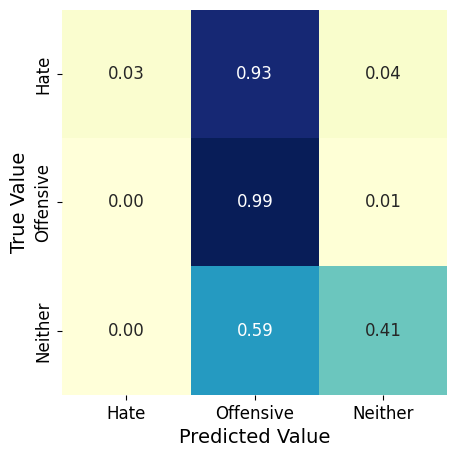

In [43]:
from sklearn.metrics import confusion_matrix 

cm = confusion_matrix(y_test,y_preds)
matrix_proportions = np.zeros((3,3))
for i in range(0,3):
    matrix_proportions[i,:] = cm[i,:]/float(cm[i,:].sum())
names=['Hate','Offensive','Neither']
confusion_df =pd.DataFrame(matrix_proportions,index=names, columns=names)
plt.figure(figsize=(5,5))
sns.heatmap(confusion_df,annot=True,annot_kws={"size": 12},cmap='YlGnBu',cbar=False, square=True,fmt='.2f')
plt.ylabel(r'True Value',fontsize=14)
plt.xlabel(r'Predicted Value',fontsize=14)
plt.tick_params(labelsize=12)
